In [1]:
from google.colab import files
uploaded = files.upload()

Saving heart_disease_complex.csv to heart_disease_complex.csv


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix

In [14]:
dataset = pd.read_csv('heart_disease_complex.csv')
X = dataset.iloc[ : , :-1].values
y = dataset.iloc[ : , -1].values

In [25]:
print(dataset.shape)
print(dataset.isnull().sum())
print(dataset.describe)
print(dataset.info)


(350, 11)
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64
<bound method NDFrame.describe of      Age  Sex  ChestPainType  RestingBP  Cholesterol  FastingBS  MaxHR  \
0     74    1              2        169          278          1    141   
1     59    0              0        146          269          0    105   
2     61    0              2        104          294          1    109   
3     72    1              0        108          307          1    149   
4     56    1              1         96          310          1     98   
..   ...  ...            ...        ...          ...        ...    ...   
345   59    1              1        142          156          1    132   
346   33    1              1        137          196          1    177   
347   37    0              1        148          344     

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state = 42)

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [9]:
from sklearn.linear_model import LogisticRegression
regressor = LogisticRegression()
regressor.fit(X_train,y_train)

LogisticRegression()

In [11]:
y_pred = regressor.predict([[23,1,1,120,100,0,90,1,0,0]])
print(y_pred)

[1]


In [12]:
y_pred = regressor.predict(X_test)
print(y_pred)

[1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 1 1 1 0 1 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1 1 0 0 1 0 0 1 0 0 1 0 0 0 0 1 0 1 0]


In [16]:
print("Accuracy",accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

Accuracy 0.8142857142857143
[[37  6]
 [ 7 20]]


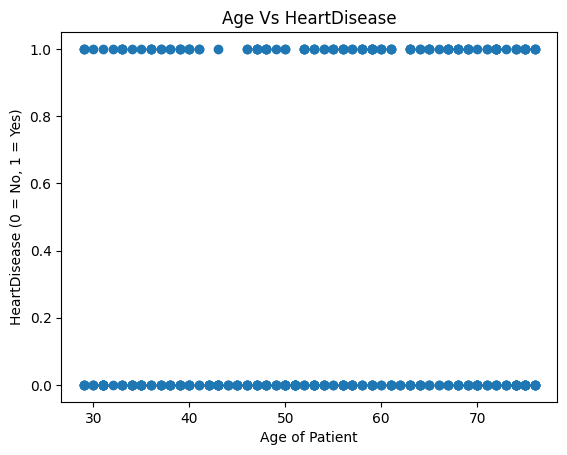

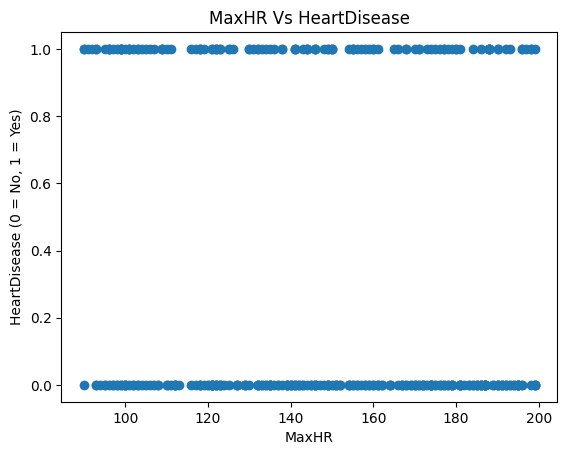

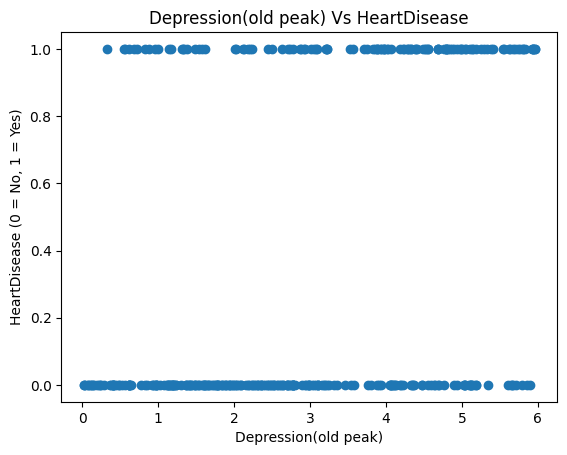

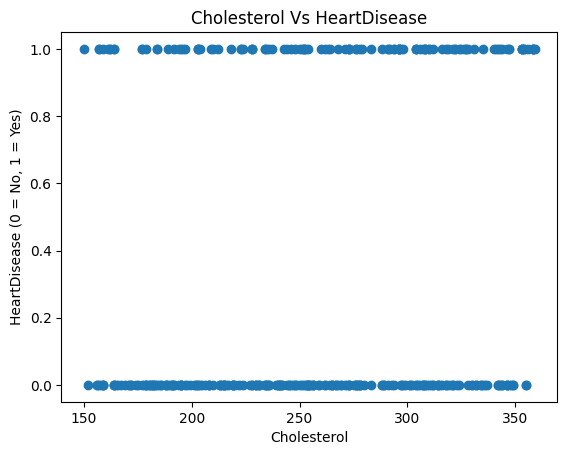

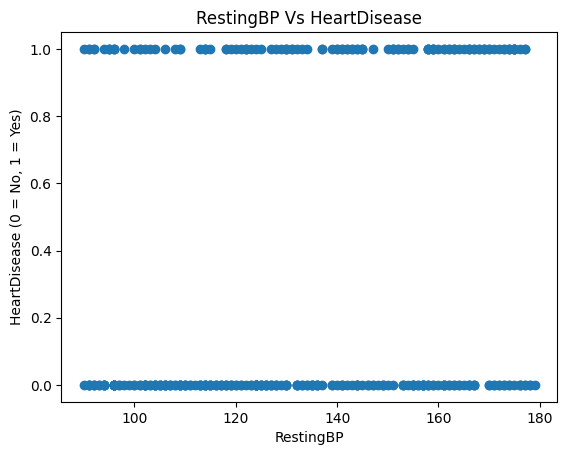

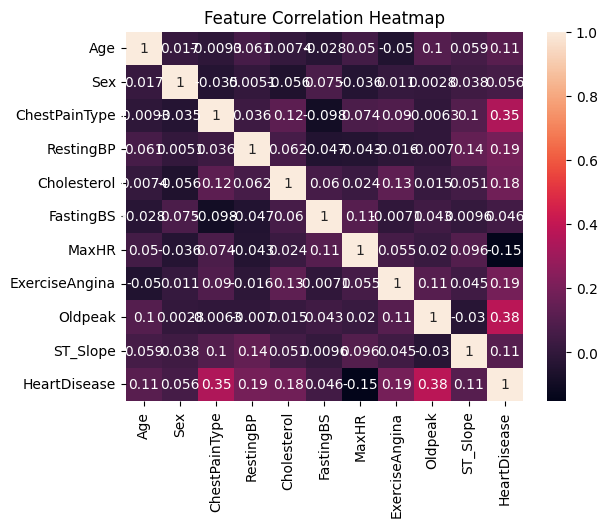

In [21]:
plt.scatter(dataset["Age"],dataset["HeartDisease"])
plt.title("Age Vs HeartDisease")
plt.xlabel("Age of Patient")
plt.ylabel("HeartDisease (0 = No, 1 = Yes)")
plt.show()

plt.scatter(dataset["MaxHR"],dataset["HeartDisease"])
plt.title("MaxHR Vs HeartDisease")
plt.xlabel("MaxHR")
plt.ylabel("HeartDisease (0 = No, 1 = Yes)")
plt.show()

plt.scatter(dataset["Oldpeak"], dataset["HeartDisease"])
plt.title("Depression(old peak) Vs HeartDisease")
plt.xlabel("Depression(old peak)")
plt.ylabel("HeartDisease (0 = No, 1 = Yes)")
plt.show()

plt.scatter(dataset["Cholesterol"], dataset["HeartDisease"])
plt.title("Cholesterol Vs HeartDisease")
plt.xlabel("Cholesterol")
plt.ylabel("HeartDisease (0 = No, 1 = Yes)")
plt.show()

plt.scatter(dataset["RestingBP"],dataset["HeartDisease"])
plt.title("RestingBP Vs HeartDisease")
plt.xlabel("RestingBP")
plt.ylabel("HeartDisease (0 = No, 1 = Yes)")
plt.show()

plt.figure()
sn.heatmap(dataset.corr(numeric_only=True), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()
